# TASK-2: Data Cleaning & Preprocessing


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
df = pd.read_csv("world_bank_data.csv")
df.head()

,country,year,gdp,population,inflation,unemployment,gdp_growth
0,Africa Eastern and Southern,2025,NaN,NaN,NaN,7.539234,NaN
1,Africa Eastern and Southern,2024,1.242694e+12,769280888.0,4.770857,7.571697,2.763839
2,Africa Eastern and Southern,2023,1.179359e+12,750491370.0,7.399186,7.676548,1.931160
3,Africa Eastern and Southern,2022,1.228968e+12,731821393.0,10.883478,7.869470,3.722717
4,Africa Eastern and Southern,2021,1.114145e+12,713090928.0,6.824727,8.407412,4.578772


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       2000 non-null   object 
 1   year          2000 non-null   int64  
 2   gdp           1876 non-null   float64
 3   population    1969 non-null   float64
 4   inflation     95 non-null     float64
 5   unemployment  1070 non-null   float64
 6   gdp_growth    1825 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 109.5+ KB


In [6]:
## Checking Missing Values
df.isnull().sum()

country            0
year               0
gdp              124
population        31
inflation       1905
unemployment     930
gdp_growth       175
dtype: int64

In [27]:
## Handling missing values
df = df.dropna(subset=["gdp", "population"])

In [28]:
## Filling gdp and unemployment with median

df.fillna({
    "gdp_growth": df["gdp_growth"].median(),
    "unemployment": df["unemployment"].median()
}, inplace=True)

In [23]:
## Dropping Inflation column as too many missing value and can reduce data quality
df = df.drop(columns=["inflation"])

In [16]:
df.isnull().sum()

country         0
year            0
gdp             0
population      0
unemployment    0
gdp_growth      0
dtype: int64

In [29]:
## Removing duplicates
df = df.drop_duplicates()

In [24]:
## Fixing data types
df["year"] = df["year"].astype(int)

In [25]:
## Sorting data 
df = df.sort_values(by=["country", "year"])

In [63]:
## Appling Feature Engineering
# GDP per capita 
df['gdp_per_capita'] = df['gdp'] / df['population']

# GDP growth category
df['growth_category'] = df['gdp_growth'].apply(
    lambda x: 'High' if x > 5 else ('Medium' if x > 2 else 'Low')
)

# Decade column for trend analysis
df['decade'] = (df['year'] // 10) * 10

In [61]:
df.head(10)

,country,year,gdp,population,unemployment,gdp_growth,gdp_per_capita,growth_category,decade
0,Africa Eastern and Southern,1960,2.420569e+10,130075728.0,6.064025,4.018631,186.089204,Medium,1960
1,Africa Eastern and Southern,1961,2.495889e+10,133534923.0,6.064025,0.418937,186.909053,Low,1960
2,Africa Eastern and Southern,1962,2.707323e+10,137171659.0,6.064025,7.937038,197.367547,High,1960
3,Africa Eastern and Southern,1963,3.176914e+10,140945536.0,6.064025,5.623764,225.400079,High,1960
4,Africa Eastern and Southern,1964,3.027955e+10,144904094.0,6.064025,4.649241,208.962717,Medium,1960
5,Africa Eastern and Southern,1965,3.380618e+10,149033472.0,6.064025,5.138168,226.836135,High,1960
6,Africa Eastern and Southern,1966,3.692725e+10,153281203.0,6.064025,4.827421,240.911794,Medium,1960
7,Africa Eastern and Southern,1967,3.844416e+10,157704381.0,6.064025,5.338839,243.773593,High,1960
8,Africa Eastern and Southern,1968,4.174200e+10,162329396.0,6.064025,4.156334,257.143823,Medium,1960
9,Africa Eastern and Southern,1969,4.704852e+10,167088245.0,6.064025,5.121587,281.578894,High,1960


In [60]:
df.to_csv("cleaned_world_bank_data.csv", index=False)

In [38]:
df = df.reset_index(drop=True)

In [43]:
df.shape

(1876, 6)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1876 entries, 0 to 1875
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       1876 non-null   object 
 1   year          1876 non-null   int64  
 2   gdp           1876 non-null   float64
 3   population    1876 non-null   float64
 4   unemployment  1876 non-null   float64
 5   gdp_growth    1876 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 88.1+ KB


**“After cleaning,there were no missing values, verified data types, and validated statistical summaries to confirm data quality. The dataset contained around 1800+ records across multiple countries and years, making it suitable for analysis.”**

# TASK-3:Exploratory Data Analysis & Visualization

In [62]:
## Basic Statistics
df.describe()

,year,gdp,population,unemployment,gdp_growth,gdp_per_capita,decade
count,1876.000000,1.876000e+03,1.876000e+03,1876.000000,1876.000000,1876.000000,1876.000000
mean,1993.187633,4.378828e+12,1.127974e+09,6.341683,3.871692,4468.975007,1988.869936
std,18.664847,8.665649e+12,1.275056e+09,1.799681,3.113993,7857.431887,18.801479
min,1960.000000,1.165303e+09,2.558348e+06,2.375768,-13.434604,71.615529,1960.000000
25%,1977.000000,2.125424e+11,3.203455e+08,5.845381,2.164969,447.211020,1970.000000
50%,1994.000000,8.984517e+11,5.892975e+08,6.064025,4.018631,1262.199617,1990.000000
75%,2009.000000,3.917841e+12,1.480459e+09,6.286884,5.633360,4674.261667,2000.000000
max,2024.000000,7.132114e+13,6.926222e+09,17.043855,22.941411,50302.605213,2020.000000


In [65]:
## category distribution analysis
df['growth_category'].value_counts()

growth_category
Medium    818
High      628
Low       430
Name: count, dtype: int64

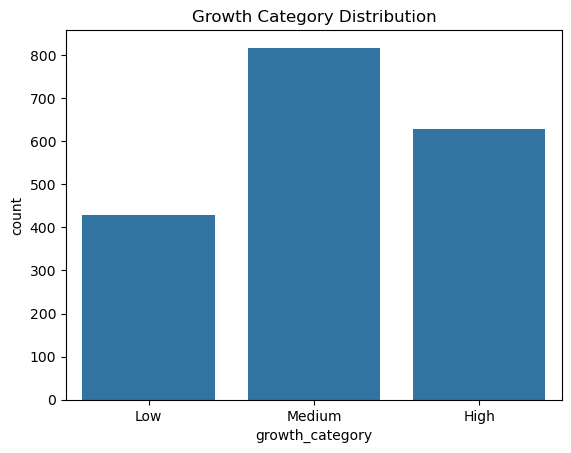

In [76]:
## Visualizing Growth Category
## displays bar chart
sns.countplot(x='growth_category', data=df,order=['Low','Medium','High']) ## Automatically counts categories
plt.title("Growth Category Distribution")
plt.show()

**Insights**
From above chart, the data is dominated by medium growth periods (44%), indicating economic stability, while high growth (33%) suggests expansion phases and low growth (23%) reflects relatively fewer downturn periods.

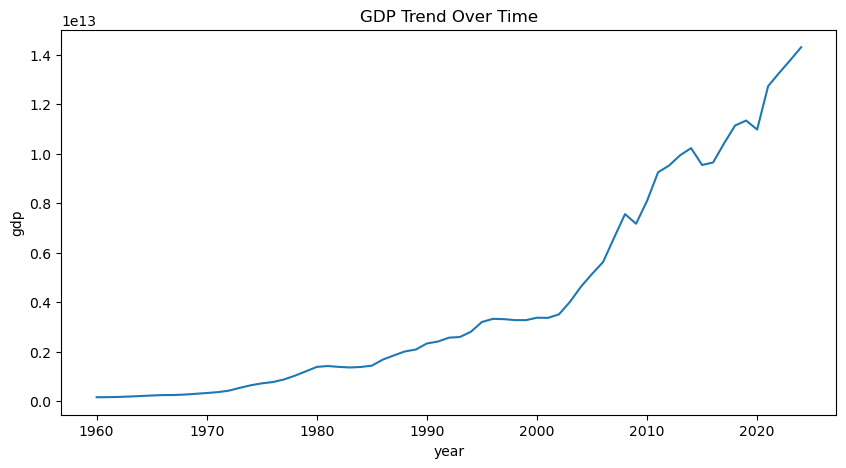

In [83]:
## Time-Based Analysis
## GDP Trend Over Time

plt.figure(figsize=(10,5))
df_year = df.groupby('year')['gdp'].mean().reset_index()
sns.lineplot(x='year', y='gdp', data=df_year)
plt.title("GDP Trend Over Time")
plt.show()

**Insights**
GDP increases from ~1e10 (1960) to ~2e13 (2024) that means massive long-term growth
Sharp rise after 2000 means Global economic expansion / industrialization

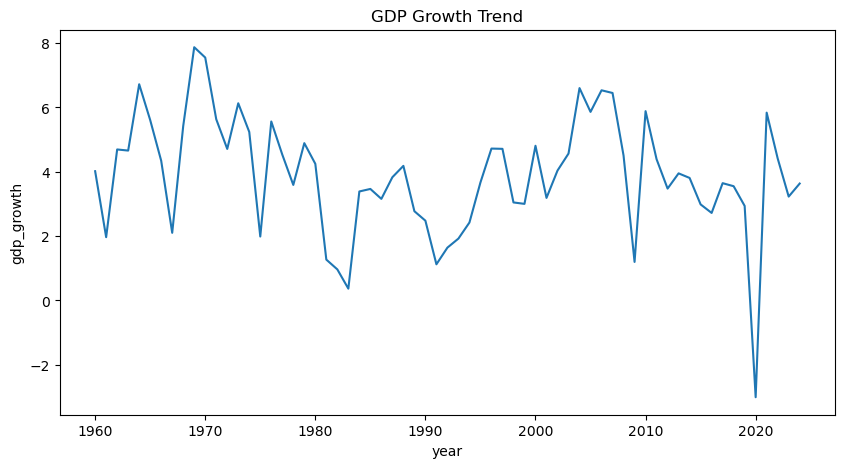

In [84]:
## GDP Growth Trend
plt.figure(figsize=(10,5))
df_year = df.groupby('year')['gdp_growth'].mean().reset_index()
sns.lineplot(x='year', y='gdp_growth', data=df_year)
plt.title("GDP Growth Trend")
plt.show()

**Insights**
GDP growth shows cyclical behavior with peaks during expansion phases and sharp declines during crises such as the 2008 financial crisis and the COVID-19 pandemic.

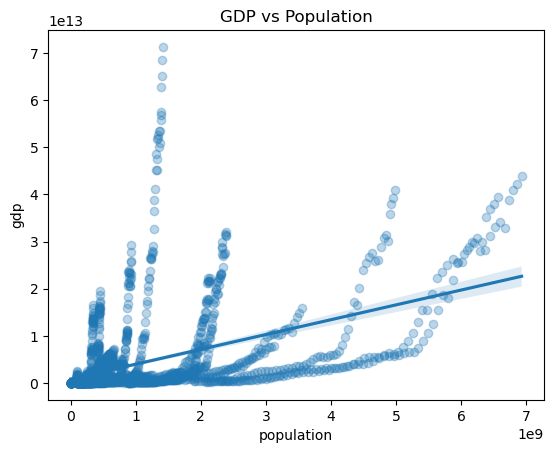

In [85]:
## Relationship Analysis
## GDP vs Population
sns.regplot(x='population', y='gdp', data=df, scatter_kws={'alpha':0.3})  ## Reduces clutter, adds regression line
plt.title("GDP vs Population")
plt.show()

**Insights**
The relationship between population and GDP is positive but not strong, indicating that economic productivity plays a more significant role than population size alone.
Used regression line to better understand trend
Upward regression line -> positive correlation

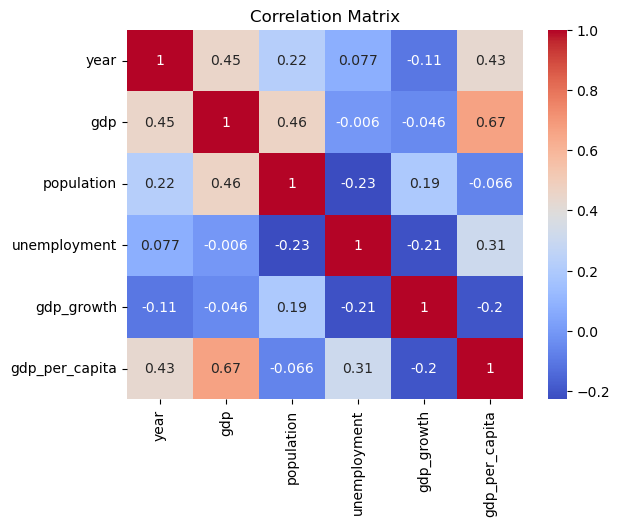

<Figure size 800x600 with 0 Axes>

In [82]:
## Correlation Heatmap
corr = df.drop(columns=['decade']).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.figure(figsize=(8,6))
plt.show()

**Insights**
Correlation analysis shows GDP is moderately correlated with population and strongly with GDP per capita, while unemployment has a negative relationship with GDP growth, indicating economic slowdown during high unemployment periods

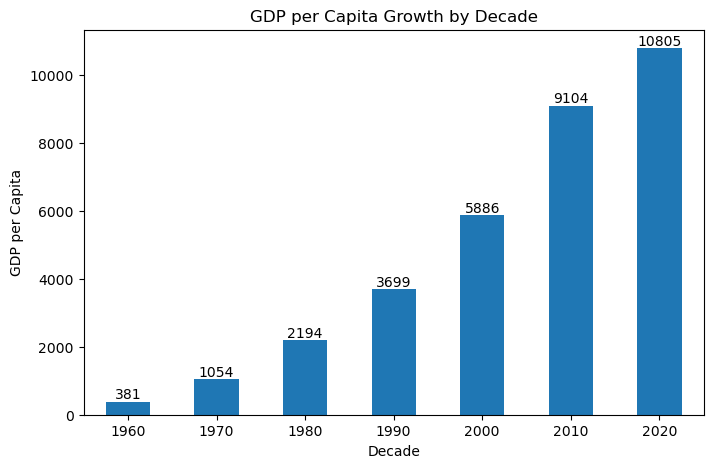

In [89]:
## Time-based Aggregated Bar Chart
df_decade = df.groupby('decade')['gdp_per_capita'].mean()

ax = df_decade.plot(kind='bar', figsize=(8,5))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("GDP per Capita Growth by Decade")
plt.ylabel("GDP per Capita")
plt.xlabel("Decade")
plt.xticks(rotation=0)
plt.show()

**Key Insights**
1.Continuous Growth: GDP per capita increases every decade
since no decline so it shows strong long-term development

2. Acceleration After 2000
3. Economic Transformation indicates industrialization,globalization,technological advancement

# TASK-4:  MACHINE LEARNING MODEL
Since dataset has continuos variables -> can predict GDP growth.

Therefore, selected a regression model to predict GDP growth using economic indicators such as GDP, population, unemployment, and GDP per capita



In [92]:
## 1. Defining Features & Target

x = df[['gdp', 'population', 'unemployment', 'gdp_per_capita']]
y = df['gdp_growth']

## x → input features (independent variables)
## y → target variable
## This will directly influence economic growth

In [94]:
## 2. Training -Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Prevent overfitting
## Evaluate model performance on unseen data

In [97]:
## 3. Train Model (Linear Regression)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)   ## fit() → learns relationship between features & target

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [98]:
## 4. Predictions
## Model predicts GDP growth for test data
y_pred = model.predict(X_test)

In [99]:
## Evaluation

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 9.334582161064299
R2 Score: 0.05536404760596969


**Insight**
The initial Linear Regression model showed a low R² score (~0.05), indicating that the selected features alone are not sufficient to explain GDP growth, which is influenced by many external macroeconomic factors

In [106]:
## 5.Feature Scaling: : For improving the model

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [105]:
## 6.Random Forest Model
## Handles non-linear relationships
## Works better for real-world data

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [102]:
## 7. Evaluating new model
from sklearn.metrics import mean_squared_error, r2_score

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 7.426578400367763
Random Forest R2: 0.24844917113456944


**Insights**
The Random Forest model improved performance from an R² of 0.05 to 0.24, indicating better capture of non-linear relationships. However, the relatively low R² suggests that GDP growth is influenced by additional macroeconomic factors not present in the dataset

In [107]:
## Feature Importance
## Shows which factor impacts GDP growth most

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Importance
1      population    0.341321
3  gdp_per_capita    0.291244
0             gdp    0.224418
2    unemployment    0.143017


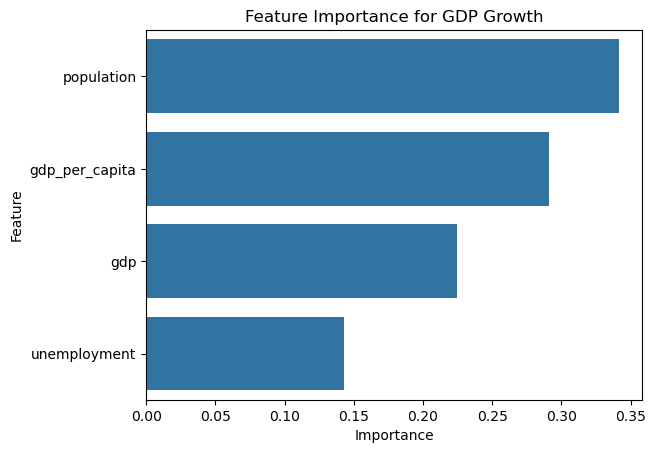

In [104]:
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance for GDP Growth")
plt.show()

**Feature importance analysis shows that population is the most influential factor in predicting GDP growth, followed by GDP per capita and GDP. Unemployment has a relatively lower impact, although it negatively affects growth. This suggests that both economic size and productivity play key roles in growth dynamics**

However, feature importance does not imply causation, and GDP growth is influenced by many external macroeconomic factors not included in the dataset.

**Business Recommendations**
1. Population Optimization:
   a. Focus on skill development and workforce training to convert population into productive human capital rather than idle workforce.
   b. Improve employment generation capacity by aligning education with industry demand to reduce mismatch in skills.
   c. Optimize resource allocation in high-population regions to ensure infrastructure, jobs, and economic participation scale together.
   
2. Improve GDP per Capita:
   a. Invest in high-value industries (technology, services, manufacturing) to increase output per individual rather than just total output.
   b. Enhance education quality and digital skills to improve workforce efficiency and earning potential.
   c. Strengthen income growth strategies (better wages, job quality) to improve overall economic performance and consumption capacity.

3. Strengthen GDP:
   a. Focus on diversifying economic sectors to reduce dependency on limited industries and ensure stable growth.
   b. Encourage exports and trade expansion to increase total economic output and global competitiveness.
   c. Develop long-term economic planning to sustain GDP growth rather than short-term spikes.

4. Reduce Unemployment:
   a.Create job opportunities through startups, MSMEs, and industrial expansion to absorb workforce efficiently.
   b.Encourage entrepreneurship and self-employment models to reduce dependency on limited job sectors.
   c.Monitor unemployment trends regularly to take early corrective actions before growth is impacted.

5. Key Optimization Strategy:
   a.Balance population size with productivity to ensure growth is driven by efficiency, not just numbers.
   b.Focus on quality of workforce rather than quantity alone for sustainable long-term growth.
   c.Integrate economic policies with workforce development and industry needs for better output.
   d.Use data-driven insights to continuously optimize resource utilization and economic planning.


# TASK-5: Interactive Dashboard using Power BI

To enhance the effectiveness of the interactive dashboard, additional derived features needs to be created from the existing dataset. These features help in better visualization, segmentation, and interpretation of economic patterns across countries.

In [119]:
## Population Growth %

df['population_growth'] = df.groupby('country')['population'].pct_change() * 100
df['population_growth'] = df['population_growth'].fillna(0)

## pct_change is Growth = (Current Year−Previous Year)/Previous Year



Population growth was calculated to analyze how changes in population impact economic indicators like GDP and GDP per capita. This helps in understanding whether economic growth is driven by productivity or simply by increasing population size.

In [120]:
## GDP Category
df['gdp_category'] = pd.cut(df['gdp'],  ## pd,cut -> converts numerical data → categories (bins)
                           bins=3, ## Dividing  GDP into 3 equal ranges
                           labels=['Low GDP','Medium GDP','High GDP'])

GDP values were categorized into segments (Low, Medium, High) to simplify comparisons across countries. This allows better grouping and filtering in the dashboard, making it easier to identify high-performing and low-performing economies.

In [114]:
df.head(10)

,country,year,gdp,population,unemployment,gdp_growth,gdp_per_capita,growth_category,decade,population_growth,gdp_category
0,Africa Eastern and Southern,1960,2.420569e+10,130075728.0,6.064025,4.018631,186.089204,Medium,1960,0.000000,Low GDP
1,Africa Eastern and Southern,1961,2.495889e+10,133534923.0,6.064025,0.418937,186.909053,Low,1960,2.659370,Low GDP
2,Africa Eastern and Southern,1962,2.707323e+10,137171659.0,6.064025,7.937038,197.367547,High,1960,2.723434,Low GDP
3,Africa Eastern and Southern,1963,3.176914e+10,140945536.0,6.064025,5.623764,225.400079,High,1960,2.751208,Low GDP
4,Africa Eastern and Southern,1964,3.027955e+10,144904094.0,6.064025,4.649241,208.962717,Medium,1960,2.808573,Low GDP
5,Africa Eastern and Southern,1965,3.380618e+10,149033472.0,6.064025,5.138168,226.836135,High,1960,2.849732,Low GDP
6,Africa Eastern and Southern,1966,3.692725e+10,153281203.0,6.064025,4.827421,240.911794,Medium,1960,2.850186,Low GDP
7,Africa Eastern and Southern,1967,3.844416e+10,157704381.0,6.064025,5.338839,243.773593,High,1960,2.885662,Low GDP
8,Africa Eastern and Southern,1968,4.174200e+10,162329396.0,6.064025,4.156334,257.143823,Medium,1960,2.932712,Low GDP
9,Africa Eastern and Southern,1969,4.704852e+10,167088245.0,6.064025,5.121587,281.578894,High,1960,2.931600,Low GDP


In [117]:
df.to_csv("cleaned_world_bank_data.csv", index=False)

# TASK-6 Video Presenation

## link: https://www.loom.com/share/99b2ff8a66994d44b6d39bcf3a235cc3